# Milestone 2 Yeild data EDA and preprocessing
## Unified Dataset Pipeline

**Goal:** Combine 4 heterogeneous datasets into a clean, analysis-ready structure.
- `crop_reco`: Soil nutrients + climate → recommended crop (standalone reference)
- `crop_yield`: State-level historical production stats (1997-2020)
- `area_production`: District-level production stats (1997-2015)
- `des_district`: District-level 2024-25 snapshot


In [1]:
import pandas as pd
import numpy as np
import re
from pathlib import Path

base_path = Path("datasets")
paths = {
    "crop_reco": base_path / "Crop Recommendation dataset.csv",
    "crop_yield": base_path / "crop_yield.csv",
    "area_production": base_path / "crop-wise-area-production-yield.csv",
    "des_district": base_path / "DES-District-Data-For-2024-25.csv",
}
xls_path = base_path / "Crop_Wise_Area_Production_Yield_codebook.xlsx"

dfs = {}
for name, path in paths.items():
    print(f"Loading {name}: {path}")
    dfs[name] = pd.read_csv(path, encoding="utf-8-sig")
    dfs[name].columns = dfs[name].columns.str.strip()

if xls_path.exists():
    try:
        xls_df = pd.read_excel(xls_path)
        xls_df.columns = xls_df.columns.astype(str).str.strip()
        dfs["codebook"] = xls_df
    except Exception as e:
        print("Could not load XLSX:", e)

for name, df in dfs.items():
    print(f"\n=== {name} === shape={df.shape}")
    print(f"  Columns: {df.columns.tolist()}")
    print(f"  Missing: {df.isna().sum().sum()} cells")


Loading crop_reco: datasets/Crop Recommendation dataset.csv
Loading crop_yield: datasets/crop_yield.csv
Loading area_production: datasets/crop-wise-area-production-yield.csv
Loading des_district: datasets/DES-District-Data-For-2024-25.csv

=== crop_reco === shape=(2200, 8)
  Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']
  Missing: 0 cells

=== crop_yield === shape=(19689, 10)
  Columns: ['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']
  Missing: 0 cells

=== area_production === shape=(455359, 16)
  Columns: ['id', 'year', 'state_name', 'state_code', 'district_name', 'district_code', 'crop_name', 'crop_code', 'crop_type', 'season', 'area', 'area_unit', 'production', 'production_unit', 'yield', 'yield_unit']
  Missing: 5030 cells

=== des_district === shape=(23282, 7)
  Columns: ['State', 'District', 'Crop', 'Season', 'Area-2024-25', 'Production-2024-25', 'Yield-2024-25']
  Missing: 56 c

## Table 1: Crop Reference (Standalone)

`crop_reco` has **no temporal/geographic keys** — it maps soil & climate conditions to recommended crops.
It stands alone as a reference table, not merged with production data.


In [2]:
crop_ref = dfs['crop_reco'].copy()
crop_ref.columns = crop_ref.columns.str.lower().str.strip()

print(f"Crop Reference Table: {crop_ref.shape}")
print(f"Crops covered: {crop_ref['label'].nunique()}")
print(crop_ref['label'].value_counts())
print("\nSample:")
print(crop_ref.head())


Crop Reference Table: (2200, 8)
Crops covered: 22
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

Sample:
    n   p   k  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


## Table 2: Unified Production Table (Union of 3 Datasets)

We **vertically stack** (union) the 3 production datasets after normalizing to a common schema.
This is cleaner than a horizontal merge which creates sparse, wide tables.

### Normalization steps per dataset:


In [3]:
def clean_text(s):
    if pd.isna(s):
        return s
    return re.sub(r'\s+', ' ', str(s).strip().lower())

def parse_year(val):
    if pd.isna(val):
        return pd.NA
    m = re.search(r'(\d{4})', str(val))
    return int(m.group(1)) if m else pd.NA

# ------------------------------------------------
# 1. CROP YIELD (state-level, 1997-2020)
# ------------------------------------------------
cy = dfs['crop_yield'].copy()
cy = cy.rename(columns={
    'Crop': 'crop', 'Crop_Year': 'year', 'Season': 'season',
    'State': 'state', 'Area': 'area', 'Production': 'production',
    'Yield': 'yield', 'Annual_Rainfall': 'annual_rainfall',
    'Fertilizer': 'fertilizer', 'Pesticide': 'pesticide'
})
# crop_yield has no district — set to NaN
cy['district'] = pd.NA
cy['data_source'] = 'crop_yield'

# Text cleanup
for col in ['crop', 'state', 'season']:
    cy[col] = cy[col].apply(clean_text)
cy['year'] = cy['year'].apply(parse_year)

print(f"crop_yield normalized: {cy.shape}")
print(f"  Years: {cy['year'].min()} - {cy['year'].max()}")
print(f"  States: {cy['state'].nunique()}")


crop_yield normalized: (19689, 12)
  Years: 1997 - 2020
  States: 30


In [4]:
# ------------------------------------------------
# 2. AREA PRODUCTION (district-level, 1997-2015)
# ------------------------------------------------
ap = dfs['area_production'].copy()
ap = ap.rename(columns={
    'state_name': 'state', 'district_name': 'district',
    'crop_name': 'crop'
})
ap['year'] = ap['year'].apply(parse_year)
ap['data_source'] = 'area_production'

# Text cleanup
for col in ['crop', 'state', 'district', 'season', 'crop_type']:
    ap[col] = ap[col].apply(clean_text)

print(f"area_production normalized: {ap.shape}")
print(f"  Years: {ap['year'].min()} - {ap['year'].max()}")
print(f"  States: {ap['state'].nunique()}")
print(f"  Districts: {ap['district'].nunique()}")


area_production normalized: (455359, 17)
  Years: 1997 - 2022
  States: 34
  Districts: 737


In [5]:
# ------------------------------------------------
# 3. DES DISTRICT (district-level, 2024-25 snapshot)
# ------------------------------------------------
des = dfs['des_district'].copy()
des = des.rename(columns={
    'State': 'state', 'District': 'district', 'Crop': 'crop',
    'Season': 'season', 'Area-2024-25': 'area',
    'Production-2024-25': 'production', 'Yield-2024-25': 'yield'
})
des['year'] = 2024
des['data_source'] = 'des_district'
des['yield'] = des['yield']/1000


for col in ['crop', 'state', 'district', 'season']:
    des[col] = des[col].apply(clean_text)

print(f"des_district normalized: {des.shape}")
print(f"  States: {des['state'].nunique()}")
print(f"  Districts: {des['district'].nunique()}")
print(f"  Crops: {des['crop'].nunique()}")


des_district normalized: (23282, 9)
  States: 29
  Districts: 669
  Crops: 19


### Defining the Common Schema

All 3 datasets share these core columns: **crop, year, state, district, season, area, production, yield**

Each also has unique extra columns. We union on the core and keep extras as auxiliary.


In [6]:
# Define common core + auxiliary columns
core_cols = ['crop', 'year', 'state', 'district', 'season', 'area', 'production', 'yield']

# Prepare each source with just the core columns + data_source
def prep_core(df, extra_cols=None):
    out = df[core_cols].copy()
    out['data_source'] = df['data_source']
    if extra_cols:
        for col in extra_cols:
            if col in df.columns:
                out[col] = df[col]
    return out

# Build each source
cy_core = prep_core(cy, extra_cols=['annual_rainfall', 'fertilizer', 'pesticide'])

ap_core = prep_core(ap, extra_cols=['crop_type', 'area_unit', 'production_unit', 'yield_unit'])

des_core = prep_core(des)

# Union all rows
production_unified = pd.concat([cy_core, ap_core, des_core], ignore_index=True, sort=False)

# Standardize types
production_unified['year'] = pd.to_numeric(production_unified['year'], errors='coerce').astype('Int64')
for col in ['area', 'production', 'yield']:
    production_unified[col] = pd.to_numeric(production_unified[col], errors='coerce')

print(f"\n=== PRODUCTION UNIFIED TABLE ===")
print(f"Shape: {production_unified.shape}")
print(f"Columns: {production_unified.columns.tolist()}")
print(f"\nRows by source:")
print(production_unified['data_source'].value_counts())
print(f"\nYears: {production_unified['year'].min()} - {production_unified['year'].max()}")
print(f"States: {production_unified['state'].nunique()}")
print(f"Districts: {production_unified['district'].nunique()}")
print(f"Crops: {production_unified['crop'].nunique()}")



=== PRODUCTION UNIFIED TABLE ===
Shape: (498330, 16)
Columns: ['crop', 'year', 'state', 'district', 'season', 'area', 'production', 'yield', 'data_source', 'annual_rainfall', 'fertilizer', 'pesticide', 'crop_type', 'area_unit', 'production_unit', 'yield_unit']

Rows by source:
data_source
area_production    455359
des_district        23282
crop_yield          19689
Name: count, dtype: int64

Years: 1997 - 2024
States: 35
Districts: 749
Crops: 125


### Handling Duplicates in the Union

Since `area_production` and `crop_yield` overlap in years (1997-2015) but at different granularities (district vs state), the same (crop, year, state, season) can appear in both. We resolve by:
1. Preferring district-level (`area_production`) over state-level (`crop_yield`) for more granularity
2. Keeping unique rows from each


In [7]:
duplicate_count = production_unified.duplicated(subset=['crop', 'year', 'state', 'season'], keep=False).sum()
print(f"Rows with same (crop, year, state, season) across sources: {duplicate_count}")

# Deduplicate: prefer area_production (district-level) > des_district > crop_yield
source_priority = {'area_production': 0, 'des_district': 1, 'crop_yield': 2}
production_unified['_priority'] = production_unified['data_source'].map(source_priority)

# Sort by priority and drop duplicates on key columns
production_unified = production_unified.sort_values('_priority')
n_before = len(production_unified)
production_unified = production_unified.drop_duplicates(
    subset=['crop', 'year', 'state', 'season', 'district'],
    keep='first'
)
production_unified = production_unified.drop(columns=['_priority'])
production_unified = production_unified[production_unified['season'] != "total"]
n_after = len(production_unified)

print(f"Deduplicated: {n_before} -> {n_after} rows ({n_before - n_after} duplicates removed)")
print(f"\nFinal rows by source:")
print(production_unified['data_source'].value_counts())


Rows with same (crop, year, state, season) across sources: 496514
Deduplicated: 498330 -> 440962 rows (57368 duplicates removed)

Final rows by source:
data_source
area_production    407315
crop_yield          19689
des_district        13958
Name: count, dtype: int64


In [8]:
COCONUT_TO_TONNES = 0.0008  # Approx. 0.8 kg per coconut

mask = production_unified["crop"].str.lower() == "coconut"

production_unified.loc[mask, "production"] *= COCONUT_TO_TONNES
production_unified.loc[mask, "yield"] *= COCONUT_TO_TONNES

season_mapping = {
    "Autumn": "Kharif",
    "Kharif": "Kharif",
    "Rabi": "Rabi",
    "Winter": "Rabi",
    "Summer": "Summer",
    "Spring": "Summer"
}

production_unified["season"] = (
    production_unified["season"]
    .str.strip()
    .replace(season_mapping)
)

## Data Quality Report

In [9]:
print("=== CROP REFERENCE TABLE ===")
print(f"Shape: {crop_ref.shape}")
print(f"Missing: {crop_ref.isna().sum().sum()} cells")
print(f"Duplicates: {crop_ref.duplicated().sum()}")
print()

print("=== PRODUCTION UNIFIED TABLE ===")
print(f"Shape: {production_unified.shape}")
print(f"Memory: {production_unified.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print()
print("Missing values per column:")
print(production_unified.isna().sum())
print()
print("Numeric summary:")
print(production_unified[['area', 'production', 'yield']].describe())


=== CROP REFERENCE TABLE ===
Shape: (2200, 8)
Missing: 0 cells
Duplicates: 0

=== PRODUCTION UNIFIED TABLE ===
Shape: (440962, 16)
Memory: 244.04 MB

Missing values per column:
crop                    0
year                    0
state                   0
district            19689
season                  0
area                    0
production           4988
yield                  15
data_source             0
annual_rainfall    421273
fertilizer         421273
pesticide          421273
crop_type           33647
area_unit           33647
production_unit     33647
yield_unit          33647
dtype: int64

Numeric summary:
               area    production          yield
count  4.409620e+05  4.359740e+05  440947.000000
mean   1.866081e+04  7.862102e+04       4.638636
std    1.647833e+05  1.277103e+06      23.275749
min    0.000000e+00  0.000000e+00       0.000000
25%    5.500000e+01  6.100000e+01       0.573000
50%    4.850000e+02  6.510000e+02       1.057000
75%    4.182000e+03  7.144000e+03

In [10]:
# Store final tables
dfs['crop_reference'] = crop_ref
dfs['production_unified'] = production_unified

print("\n=== FINAL DELIVERABLES ===")
print(f"1. crop_reference: {crop_ref.shape} — Soil/climate requirements per crop")
print(f"   Connection: crop_reference.label <-> production_unified.crop")
print(f"2. production_unified: {production_unified.shape} — Unified crop production time-series")



=== FINAL DELIVERABLES ===
1. crop_reference: (2200, 8) — Soil/climate requirements per crop
   Connection: crop_reference.label <-> production_unified.crop
2. production_unified: (440962, 16) — Unified crop production time-series


## Exploratory Data Analysis

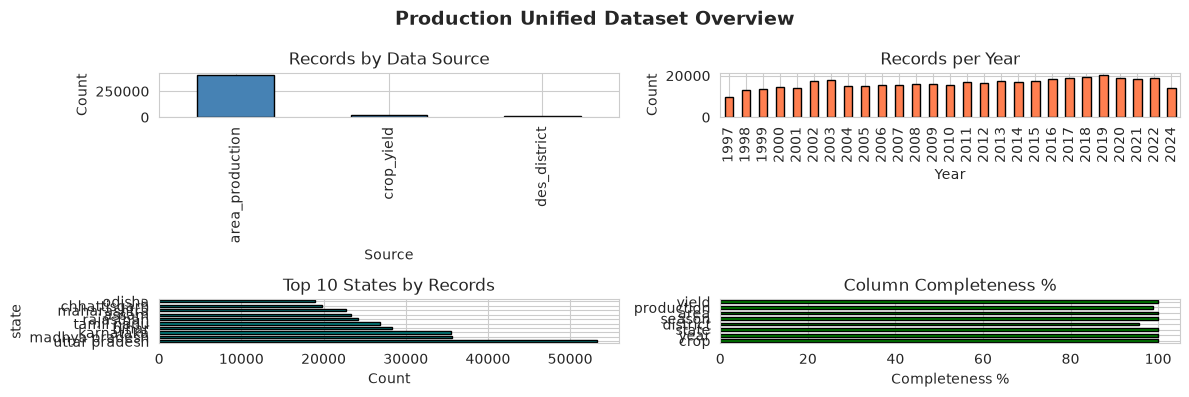

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

prod = production_unified

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Production Unified Dataset Overview", fontsize=14, fontweight='bold')

# 1. Records by data source
ax = axes[0, 0]
prod['data_source'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title("Records by Data Source")
ax.set_xlabel("Source")
ax.set_ylabel("Count")

# 2. Records by year
ax = axes[0, 1]
year_counts = prod.dropna(subset=['year'])['year'].value_counts().sort_index()
year_counts.plot(kind='bar', ax=ax, color='coral', edgecolor='black', figsize=(12,4))
ax.set_title("Records per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Count")

# 3. Top states
if 'state' in prod.columns:
    ax = axes[1, 0]
    prod['state'].value_counts().head(10).plot(kind='barh', ax=ax, color='teal', edgecolor='black')
    ax.set_title("Top 10 States by Records")
    ax.set_xlabel("Count")

# 4. Data completeness
ax = axes[1, 1]
completeness = (1 - prod[core_cols].isna().sum() / len(prod)) * 100
completeness.plot(kind='barh', ax=ax, color='green', edgecolor='black')
ax.set_title("Column Completeness %")
ax.set_xlabel("Completeness %")
ax.set_xlim([0, 105])

plt.tight_layout()
plt.show()


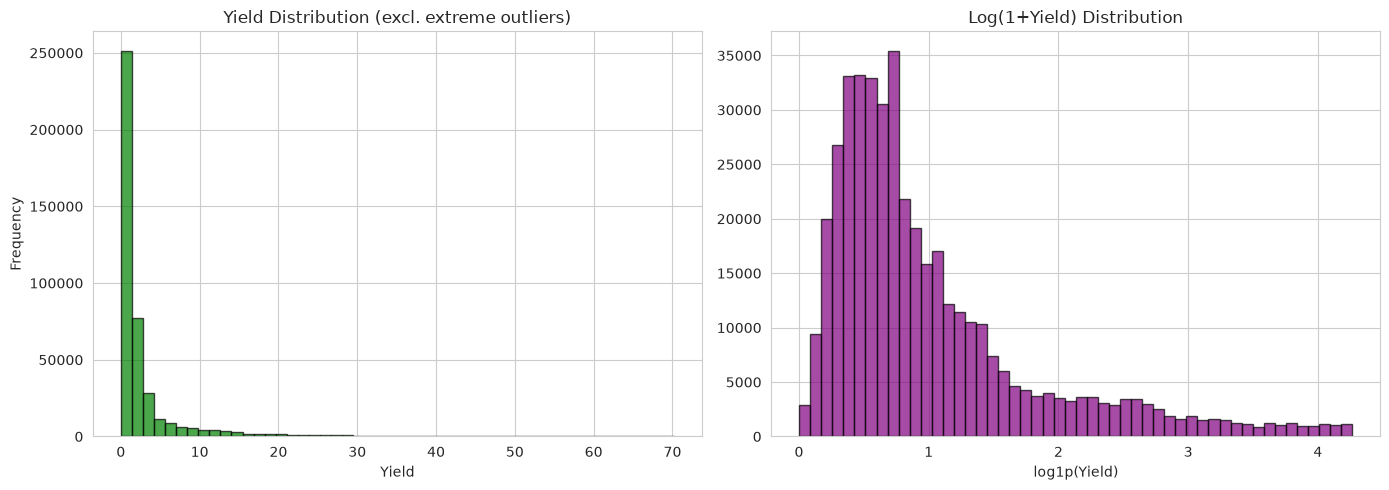

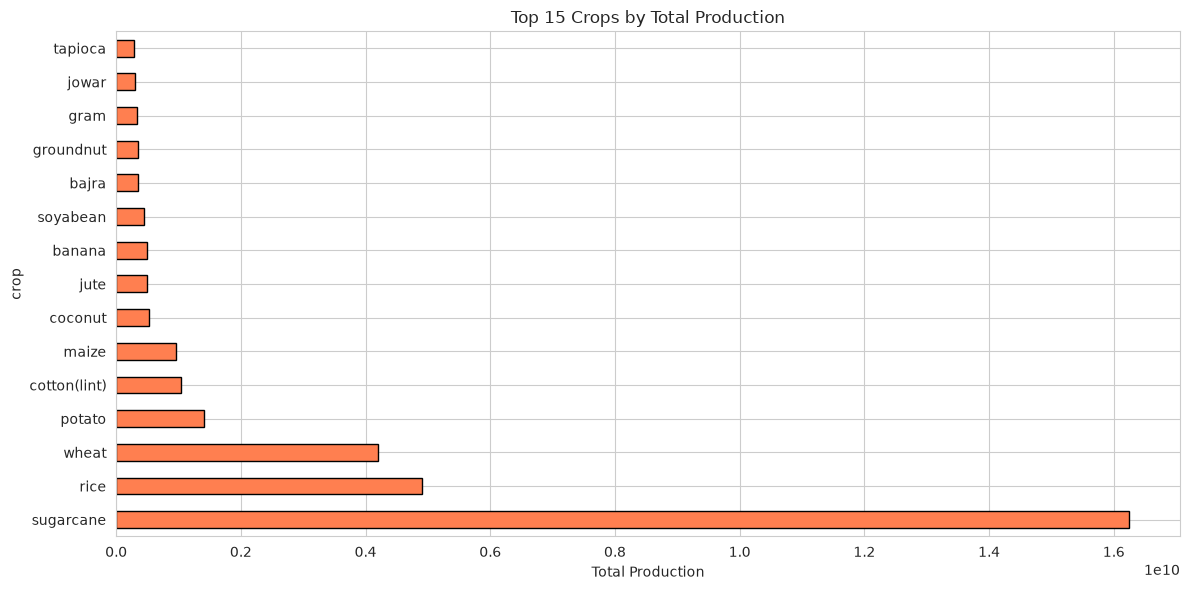

In [12]:
# Yield distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Filter reasonable yield values
valid = prod[(prod['yield'] > 0) & (prod['yield'] < prod['yield'].quantile(0.99))]
valid['yield'].hist(bins=50, ax=axes[0], edgecolor='black', alpha=0.7, color='green')
axes[0].set_title("Yield Distribution (excl. extreme outliers)")
axes[0].set_xlabel("Yield")
axes[0].set_ylabel("Frequency")

# Log scale
np.log1p(valid['yield']).hist(bins=50, ax=axes[1], edgecolor='black', alpha=0.7, color='purple')
axes[1].set_title("Log(1+Yield) Distribution")
axes[1].set_xlabel("log1p(Yield)")

plt.tight_layout()
plt.show()

# Top crops by production
crop_prod = prod.groupby('crop')['production'].sum().nlargest(15)
fig, ax = plt.subplots(figsize=(12, 6))
crop_prod.plot(kind='barh', ax=ax, color='coral', edgecolor='black')
ax.set_title("Top 15 Crops by Total Production")
ax.set_xlabel("Total Production")
plt.tight_layout()
plt.show()


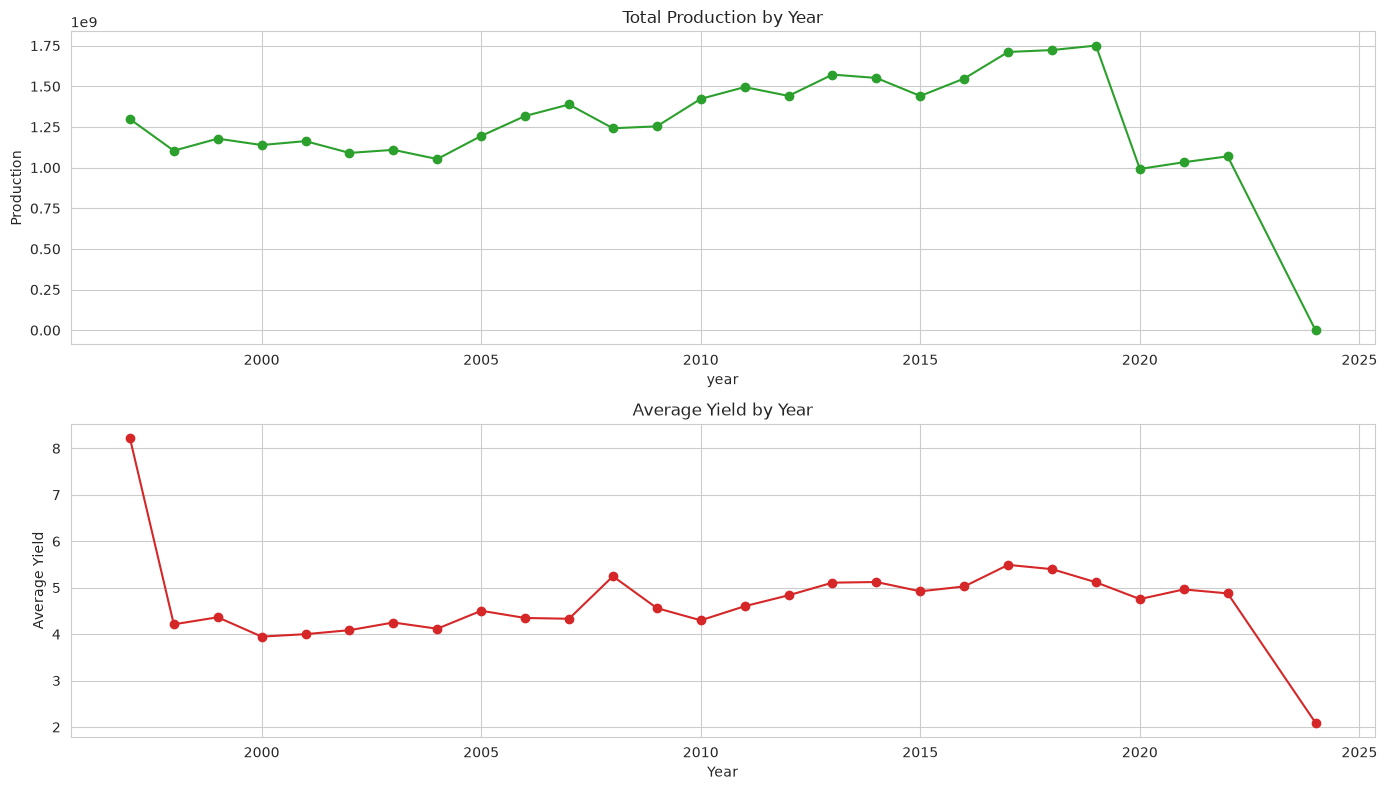

In [13]:
# Time-series: Production and Yield trends
if prod['year'].notna().any():
    yearly = prod.dropna(subset=['year', 'production'])
    yearly = yearly[yearly['year'] > 0]
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    prod_by_year = yearly.groupby('year')['production'].sum()
    prod_by_year.plot(ax=axes[0], marker='o', color='C2')
    axes[0].set_title("Total Production by Year")
    axes[0].set_ylabel("Production")
    
    yield_by_year = yearly.groupby('year')['yield'].mean()
    yield_by_year.plot(ax=axes[1], marker='o', color='C3')
    axes[1].set_title("Average Yield by Year")
    axes[1].set_ylabel("Average Yield")
    axes[1].set_xlabel("Year")
    
    plt.tight_layout()
    plt.show()


# Before Imputing EDA

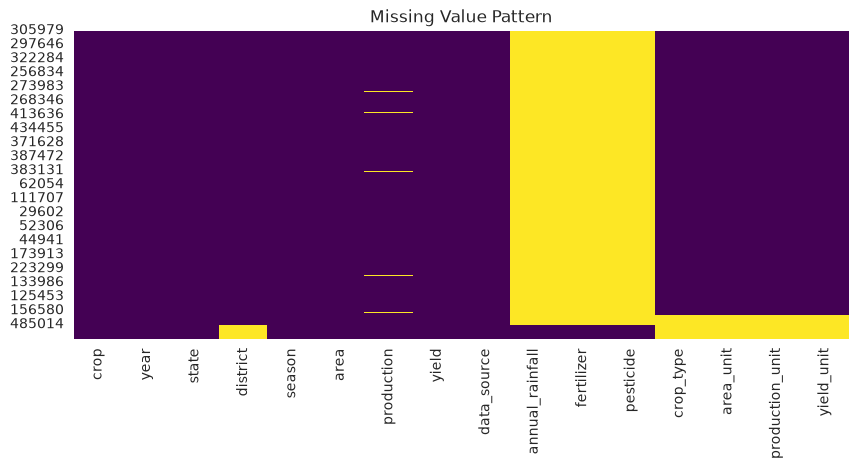

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
sns.heatmap(prod.isna(), cbar=False, cmap="viridis")
plt.title("Missing Value Pattern")
plt.show()

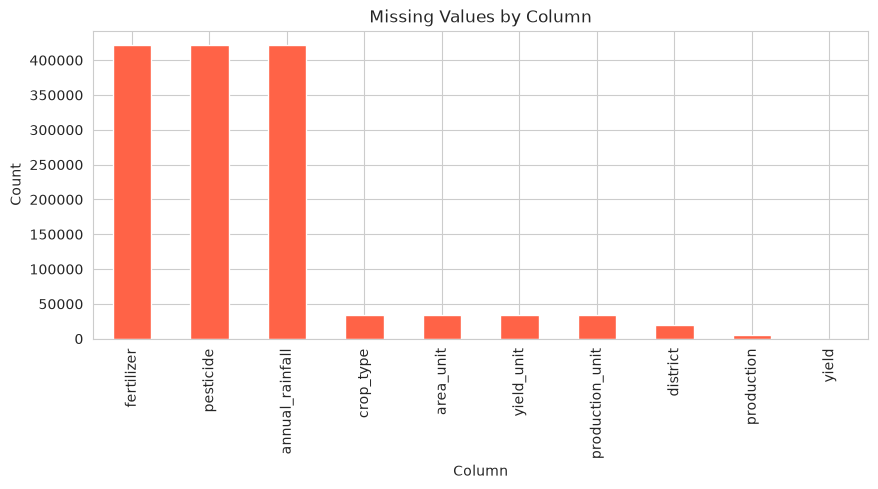

In [15]:
missing = prod.isna().sum().sort_values(ascending=False)
missing[missing > 0].plot(kind="bar", figsize=(10, 4), color="tomato")
plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Count")
plt.show()

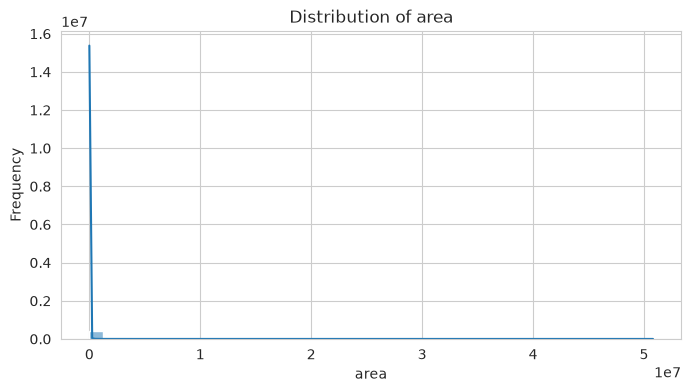

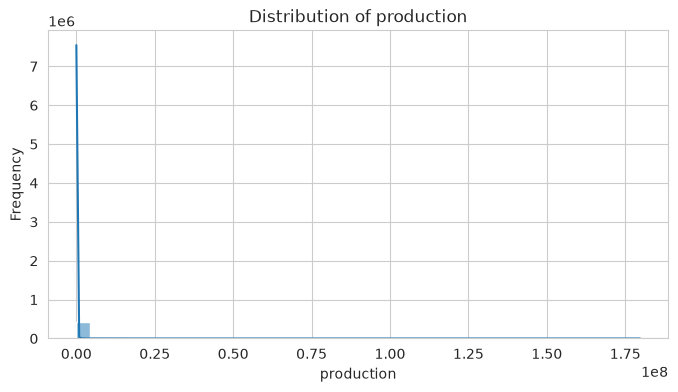

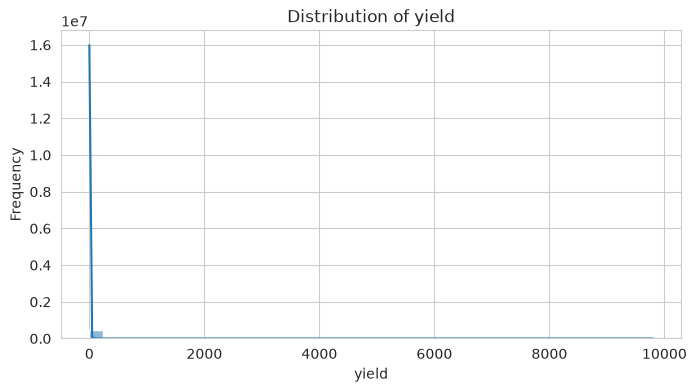

In [16]:
for col in ["area", "production", "yield"]:
    if col in prod.columns:
        plt.figure(figsize=(8, 4))
        sns.histplot(prod[col].dropna(), bins=40, kde=True)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

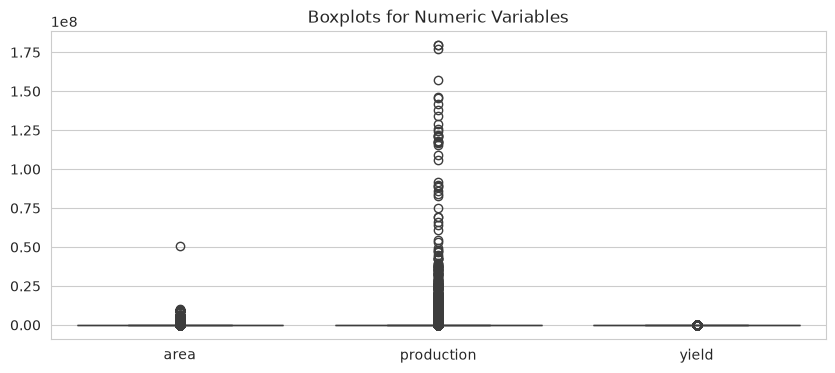

In [17]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=prod[["area", "production", "yield"]].dropna())
plt.title("Boxplots for Numeric Variables")
plt.show()

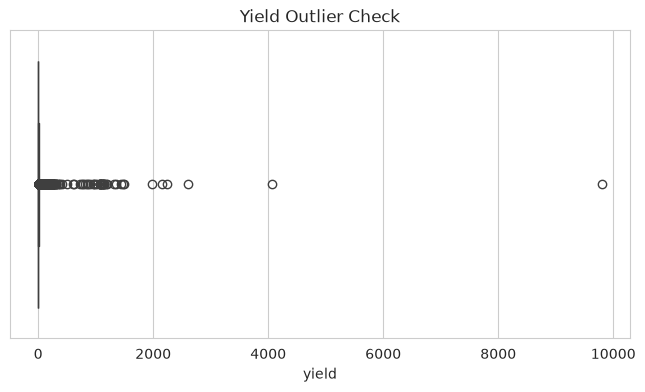

In [18]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=prod["yield"].dropna())
plt.title("Yield Outlier Check")
plt.show()

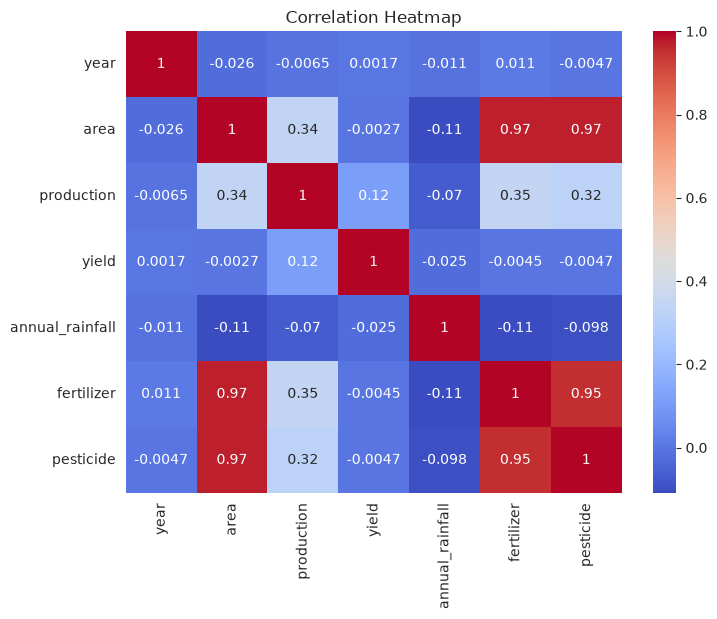

In [19]:
num_cols = prod.select_dtypes(include=["number"]).columns
corr = prod[num_cols].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

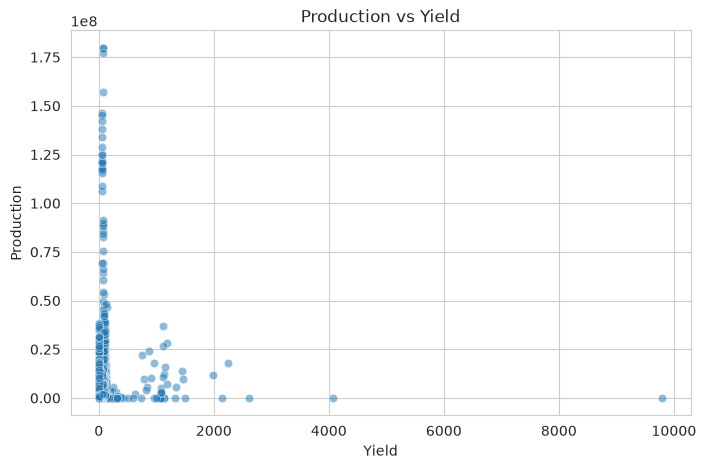

In [20]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=prod.dropna(subset=["production", "yield"]),
                x="yield", y="production", alpha=0.5)
plt.title("Production vs Yield")
plt.xlabel("Yield")
plt.ylabel("Production")
plt.show()

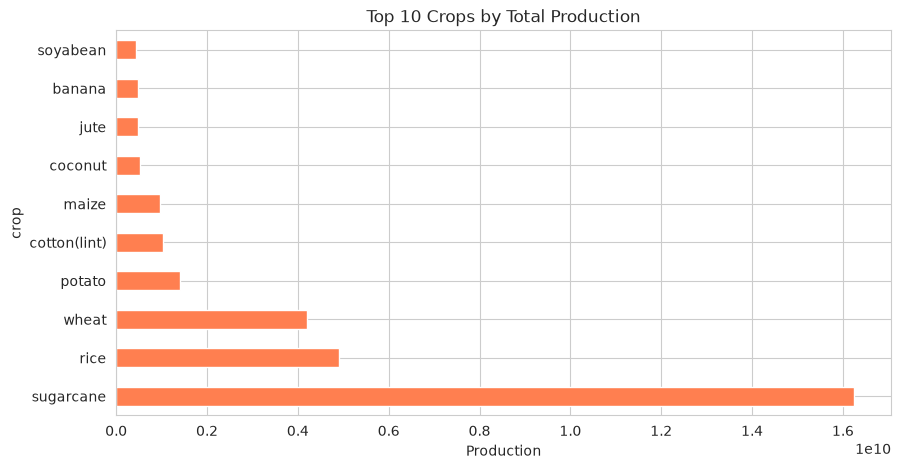

In [21]:
top_crops = prod.groupby("crop")["production"].sum().sort_values(ascending=False).head(10)
top_crops.plot(kind="barh", figsize=(10, 5), color="coral")
plt.title("Top 10 Crops by Total Production")
plt.xlabel("Production")
plt.show()

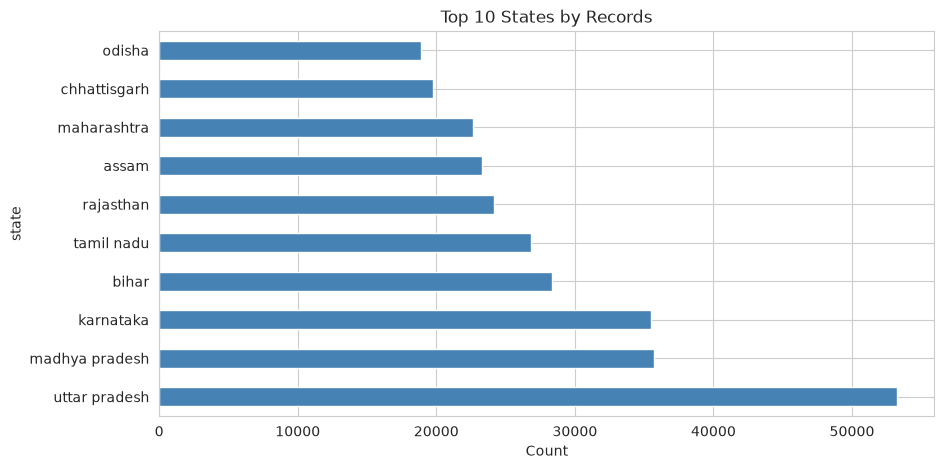

In [22]:
prod["state"].value_counts().head(10).plot(kind="barh", figsize=(10, 5), color="steelblue")
plt.title("Top 10 States by Records")
plt.xlabel("Count")
plt.show()

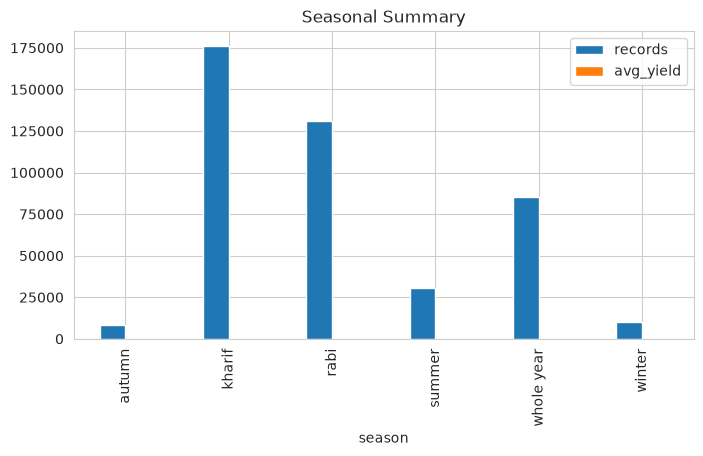

In [23]:
season_summary = prod.groupby("season").agg(
    records=("season", "size"),
    avg_yield=("yield", "mean")
)
season_summary.plot(kind="bar", figsize=(8, 4))
plt.title("Seasonal Summary")
plt.show()

In [24]:
print("EDA Summary")
print("-" * 40)
print(f"Rows: {len(prod)}")
print(f"Missing values: {prod.isna().sum().sum()}")
print(f"Unique crops: {prod['crop'].nunique()}")
print(f"Unique states: {prod['state'].nunique()}")
print(f"Years covered: {prod['year'].min()} to {prod['year'].max()}")

EDA Summary
----------------------------------------
Rows: 440962
Missing values: 1423099
Unique crops: 124
Unique states: 35
Years covered: 1997 to 2024


In [25]:
# Export to CSV
production_unified.to_csv('production_unified.csv', index=False)
print(f"Exported: production_unified.csv ({production_unified.shape[0]:,} rows, {production_unified.shape[1]} cols)")
print(f"Size: {Path('production_unified.csv').stat().st_size / 1024**2:.2f} MB")


Exported: production_unified.csv (440,962 rows, 16 cols)
Size: 48.64 MB


## Pre-processing   

In [26]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from missforest import MissForest


df = production_unified.copy()

# Identify categorical and numeric columns robustly.
cat_cols = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
num_cols = df.select_dtypes(include=["number"]).columns.tolist()

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

# Replace pandas nullable missing values with numpy-style missing values
# so scikit-learn can process the data safely.
for col in cat_cols:
    df[col] = df[col].astype("object")
    df[col] = df[col].where(df[col].notna(), np.nan)



cat_imputer = SimpleImputer(strategy="most_frequent")

df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])



encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

df[cat_cols] = encoder.fit_transform(df[cat_cols])


# MISSFOREST IMPUTATION


imputer = MissForest(verbose=0)

df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)


df[cat_cols] = encoder.inverse_transform(df[cat_cols])


print(df.isnull().sum())

# Final dataframe
post_production_unified = df.copy()

Numerical Columns: ['year', 'area', 'production', 'yield', 'annual_rainfall', 'fertilizer', 'pesticide']
Categorical Columns: ['crop', 'state', 'district', 'season', 'data_source', 'crop_type', 'area_unit', 'production_unit', 'yield_unit']


crop               0
year               0
state              0
district           0
season             0
area               0
production         0
yield              0
data_source        0
annual_rainfall    0
fertilizer         0
pesticide          0
crop_type          0
area_unit          0
production_unit    0
yield_unit         0
dtype: int64


In [27]:
df.to_csv('production_unified_imputed.csv', index=False)

## Post-EDA

This section summarizes the cleaned dataset after imputation and highlights the main patterns in production, yield, and seasonality.

Post-EDA Summary
----------------------------------------
Rows: 440962
Columns: 16
Years covered: 1997 to 2024
Crops: 124
States: 35
Seasons: <StringArray>
['rabi', 'summer', 'kharif', 'whole year', 'winter', 'autumn']
Length: 6, dtype: str

Top crops by total production:
              records  total_production  avg_yield
crop                                              
sugarcane       13084      1.624915e+10  57.888529
rice            27304      4.912531e+09   2.207029
wheat           13901      4.199338e+09   2.292024
potato          13083      1.411726e+09  13.202363
cotton(lint)     8101      1.034328e+09   2.102376
maize           26549      9.641720e+08   2.774880
coconut          3475      5.316648e+08   7.092603
jute             2357      4.882976e+08   9.483241
banana           5407      4.868624e+08  29.864450
soyabean         6360      4.438694e+08   1.085533


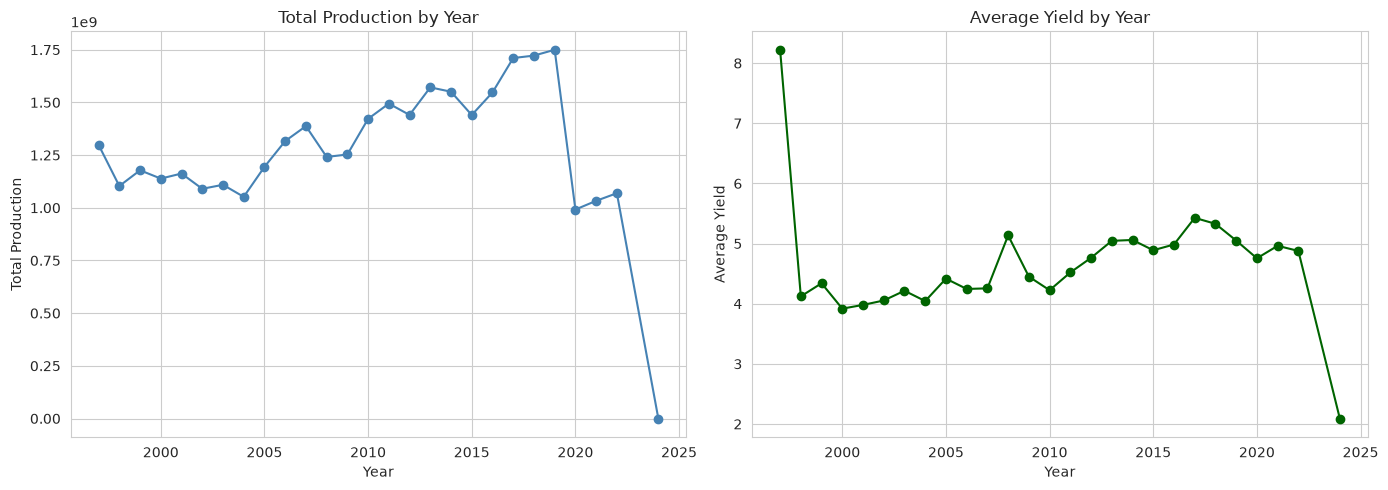


Season summary:
            records  avg_yield  total_production
season                                          
whole year    85120  13.114690      1.320604e+10
winter        10005   6.032973      1.288622e+09
summer        30288   3.401560      5.409137e+08
autumn         8448   2.482738      1.832725e+08
kharif       176396   2.477083      1.237665e+10
rabi         130705   2.354736      6.671706e+09


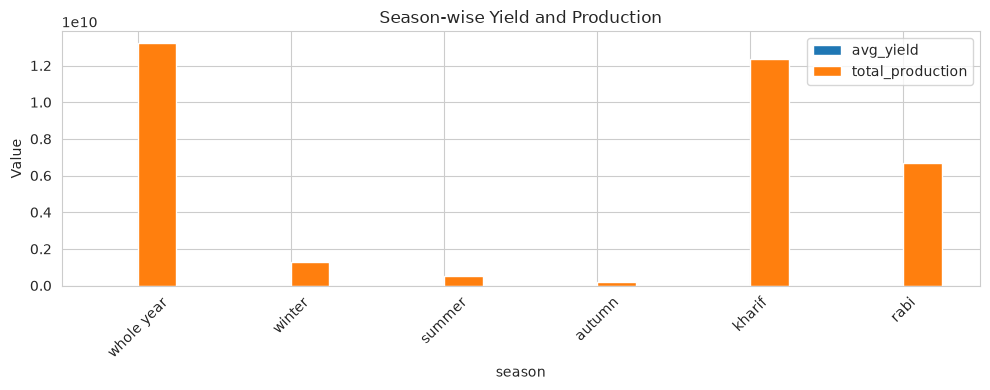

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Basic dataset summary
print('Post-EDA Summary')
print('-' * 40)
print(f"Rows: {production_unified.shape[0]}")
print(f"Columns: {production_unified.shape[1]}")
print(f"Years covered: {production_unified['year'].min()} to {production_unified['year'].max()}")
print(f"Crops: {production_unified['crop'].nunique()}")
print(f"States: {production_unified['state'].nunique()}")
print(f"Seasons: {production_unified['season'].dropna().unique()}")

# Top crops by average yield
crop_yield_summary = (
    post_production_unified.groupby('crop')
    .agg(records=('crop', 'size'), total_production=('production', 'sum'), avg_yield=('yield', 'mean'))
    .sort_values('total_production', ascending=False)
)
print('\nTop crops by total production:')
print(crop_yield_summary.head(10))

# Trend by year
yearly_summary = (
    post_production_unified.groupby('year')
    .agg(total_production=('production', 'sum'), avg_yield=('yield', 'mean'))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(yearly_summary['year'], yearly_summary['total_production'], marker='o', color='steelblue')
axes[0].set_title('Total Production by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Production')

axes[1].plot(yearly_summary['year'], yearly_summary['avg_yield'], marker='o', color='darkgreen')
axes[1].set_title('Average Yield by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Yield')

plt.tight_layout()
plt.show()

# Season-wise comparison
season_summary = (
    post_production_unified.groupby('season')
    .agg(records=('season', 'size'), avg_yield=('yield', 'mean'), total_production=('production', 'sum'))
    .sort_values('avg_yield', ascending=False)
)
print('\nSeason summary:')
print(season_summary)

season_summary[['avg_yield', 'total_production']].plot(kind='bar', figsize=(10, 4))
plt.title('Season-wise Yield and Production')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Top 10 states by production:
                total_production  avg_yield  records
state                                               
uttar pradesh       9.838716e+09   5.603245    53266
maharashtra         4.241288e+09   3.638722    22671
tamil nadu          2.642531e+09   9.175246    26812
karnataka           2.526677e+09   4.324559    35469
west bengal         1.907157e+09   5.532284    15355
madhya pradesh      1.850498e+09   3.451353    35681
gujarat             1.762349e+09   5.537014    18097
punjab              1.678863e+09   6.920919     5406
andhra pradesh      1.645926e+09   6.719320    16222
haryana             1.256798e+09   6.382593    10262


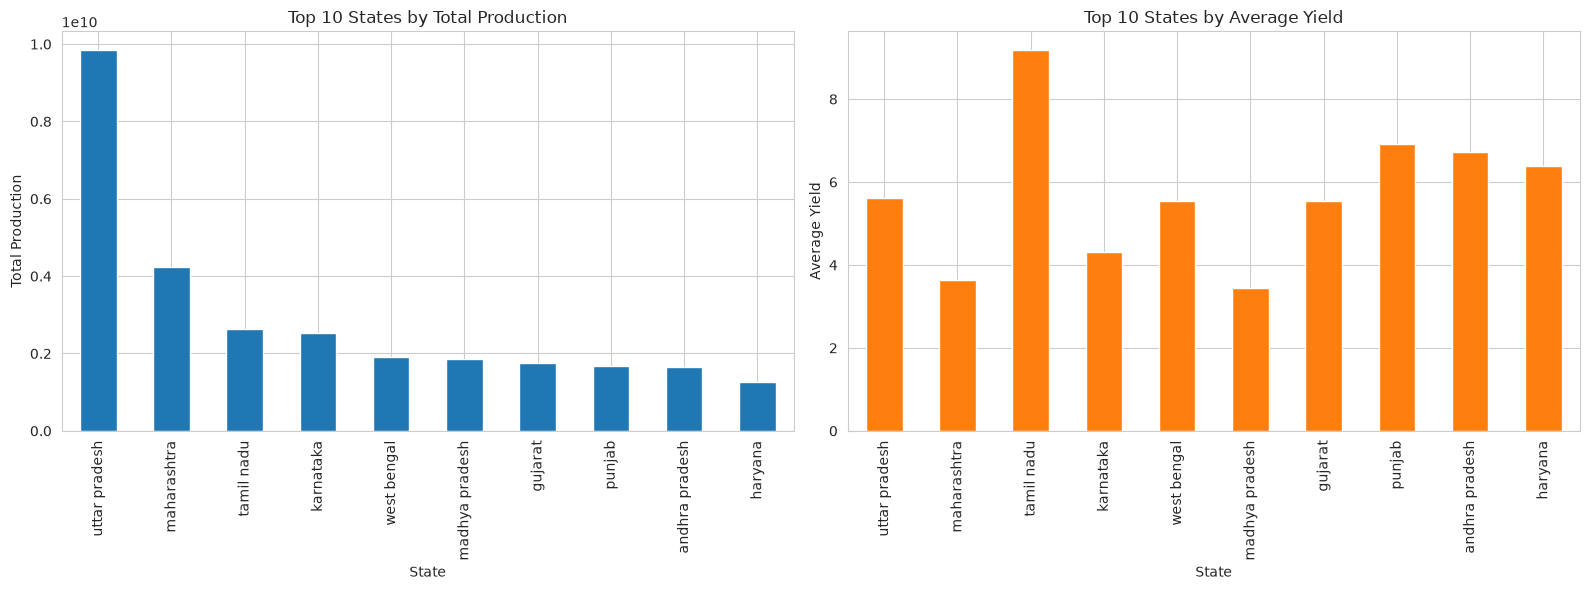


Seasonal production for top crops:
season              autumn        kharif          rabi        summer  \
crop                                                                   
coconut       0.000000e+00 -8.030521e+03  0.000000e+00  0.000000e+00   
cotton(lint)  4.000000e+01  1.007519e+09  3.780423e+06  3.906200e+04   
jute          9.511640e+05  4.872878e+08  5.859270e+04  4.000000e+01   
maize         3.040438e+07  6.606241e+08  2.073407e+08  5.298943e+07   
potato        3.340000e+03  1.495941e+07  8.150899e+08  3.157333e+06   
rice          1.486008e+08  2.901026e+09  2.746390e+08  3.744456e+08   
sugarcane     6.023845e+04  5.413428e+09  9.303200e+04  9.800000e+03   
wheat         0.000000e+00 -9.930855e+03  4.181404e+09  1.076763e+05   

season          whole year        winter  
crop                                      
coconut       5.316728e+08  0.000000e+00  
cotton(lint)  2.298962e+07  2.000000e+01  
jute          0.000000e+00  0.000000e+00  
maize         1.269819e+07  

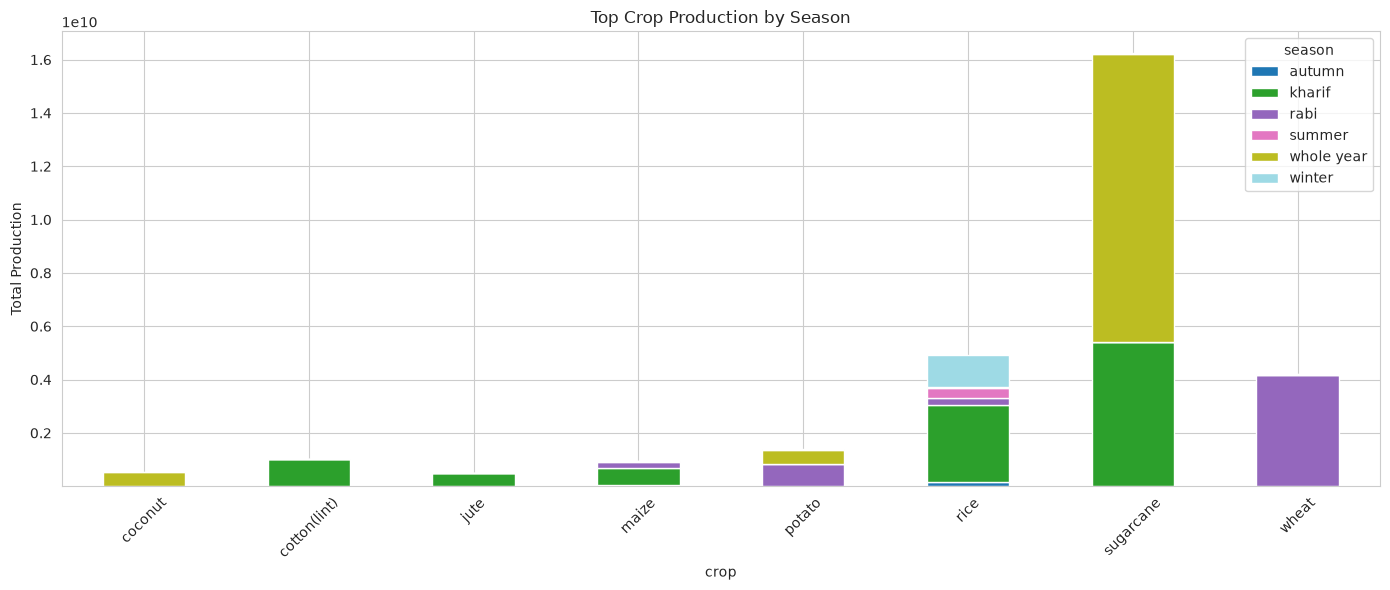


Numeric correlation matrix:
                     area  production     yield  annual_rainfall  fertilizer  \
area             1.000000    0.340974 -0.002695        -0.050383    0.939063   
production       0.340974    1.000000  0.115775        -0.039030    0.346607   
yield           -0.002695    0.115775  1.000000        -0.004214   -0.001022   
annual_rainfall -0.050383   -0.039030 -0.004214         1.000000   -0.053289   
fertilizer       0.939063    0.346607 -0.001022        -0.053289    1.000000   
pesticide        0.938948    0.321706 -0.000999        -0.046940    0.956783   

                 pesticide  
area              0.938948  
production        0.321706  
yield            -0.000999  
annual_rainfall  -0.046940  
fertilizer        0.956783  
pesticide         1.000000  


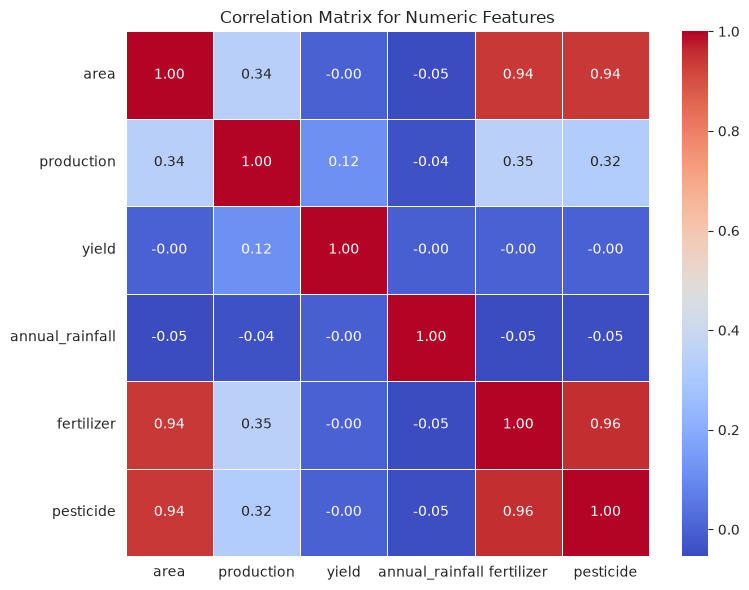

In [30]:

## Additional Post-EDA Insights

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Top states by total production and average yield
state_summary = (
    post_production_unified.groupby('state')
    .agg(total_production=('production', 'sum'), avg_yield=('yield', 'mean'), records=('state', 'size'))
    .sort_values('total_production', ascending=False)
)
print('Top 10 states by production:')
print(state_summary.head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
state_summary.head(10)['total_production'].plot(kind='bar', ax=axes[0], color='tab:blue')
axes[0].set_title('Top 10 States by Total Production')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Total Production')

state_summary.head(10)['avg_yield'].plot(kind='bar', ax=axes[1], color='tab:orange')
axes[1].set_title('Top 10 States by Average Yield')
axes[1].set_xlabel('State')
axes[1].set_ylabel('Average Yield')
plt.tight_layout()
plt.show()

# Production patterns for top crops across seasons
top_crops = crop_yield_summary.head(8).index.tolist()
season_crop = (
    post_production_unified[post_production_unified['crop'].isin(top_crops)]
    .groupby(['crop', 'season'])
    .agg(total_production=('production', 'sum'), avg_yield=('yield', 'mean'))
    .reset_index()
)

pivot_prod = season_crop.pivot(index='crop', columns='season', values='total_production').fillna(0)
print('\nSeasonal production for top crops:')
print(pivot_prod)

pivot_prod.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='tab20')
plt.title('Top Crop Production by Season')
plt.ylabel('Total Production')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Numeric correlation after cleaning
numeric_cols = ['area', 'production', 'yield', 'annual_rainfall', 'fertilizer', 'pesticide']
correlation = post_production_unified[numeric_cols].corr()
print('\nNumeric correlation matrix:')
print(correlation)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix for Numeric Features')
plt.tight_layout()
plt.show()
